# Multi-State Grain Size Analysis with `stamp.pipeline`

This notebook demonstrates `stamp.pipeline.run_batch()` on three material states
(heat treatment conditions) each measured over 10 fields of view (FOVs).

**Data format** — each state is stored in a single batch CSV file where every
row represents one grain measurement and is identified by a label in the form
`<state>_<fov_id>_<grain_id>`, e.g. `As-received_fov01_grain003`.  The pipeline
extracts the FOV grouping from the label automatically.

**Workflow**
1. Simulate batch-format CSV data for each material state.
2. Analyse the **apparent (2D)** diameters — box plots and summary CSV.
3. Apply the **two-step stereological correction** per FOV to recover the 3D distribution.
4. Analyse the **corrected (3D)** diameters — box plots and summary CSV.
5. Compare apparent vs corrected geometric means against the simulation ground truth.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import stamp.pipeline as pipeline
from stamp.pipeline import run_batch
from stamp.simulate import simulate_section
from stamp.stereo import two_step

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("notebooks/data/multi_state_batch")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Simulate batch-format data

Three steel specimens with increasing grain sizes (progressive annealing).
10 FOVs per state, 150 apparent grain diameter measurements per FOV.
All FOVs for each state are combined into a single batch CSV with labelled rows.

In [2]:
# Material states: true 3D geometric mean (mu) and log-scale sigma
STATES = {
    "As-received":    {"mu": 5.0,  "sigma": 0.35},
    "Annealed_600C":  {"mu": 10.0, "sigma": 0.30},
    "Annealed_900C":  {"mu": 20.0, "sigma": 0.28},
}

N_FOVS = 10
N_GRAINS_PER_FOV = 150

rng_master = np.random.default_rng(42)
seeds = rng_master.integers(0, 99_999, size=(len(STATES), N_FOVS))

apparent_batch_files = {}   # state name -> Path

for s_idx, (state_name, params) in enumerate(STATES.items()):
    rows = []
    for fov_idx in range(N_FOVS):
        fov_label = f"fov{fov_idx + 1:02d}"
        seed = int(seeds[s_idx, fov_idx])
        sim = simulate_section(
            mu=params["mu"],
            sigma=params["sigma"],
            n_intersections=N_GRAINS_PER_FOV,
            n_grains=5000,
            seed=seed,
            unit="µm",
        )
        for grain_idx, val in enumerate(sim.apparent_diameters.values, start=1):
            rows.append({
                "label": f"{state_name}_{fov_label}_grain{grain_idx:03d}",
                "diameter_um": val,
            })

    csv_path = DATA_DIR / f"{state_name}_apparent.csv"
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    apparent_batch_files[state_name] = csv_path

print("Batch CSV files written (apparent 2D diameters):")
for state, path in apparent_batch_files.items():
    df = pd.read_csv(path)
    print(f"  {path.name:40s}  {len(df):5d} rows  ({N_FOVS} FOVs × {N_GRAINS_PER_FOV} grains)")

print("\nFirst 6 rows of As-received batch file:")
display(pd.read_csv(apparent_batch_files["As-received"]).head(6))

Batch CSV files written (apparent 2D diameters):
  As-received_apparent.csv                   1500 rows  (10 FOVs × 150 grains)
  Annealed_600C_apparent.csv                 1500 rows  (10 FOVs × 150 grains)
  Annealed_900C_apparent.csv                 1500 rows  (10 FOVs × 150 grains)

First 6 rows of As-received batch file:


,label,diameter_um
0,As-received_fov01_grain001,5.355569
1,As-received_fov01_grain002,7.499348
2,As-received_fov01_grain003,3.886727
3,As-received_fov01_grain004,4.696075
4,As-received_fov01_grain005,5.656438
5,As-received_fov01_grain006,6.154498


## 2. Apparent (2D) diameter pipeline

`run_batch()` reads each batch CSV, extracts the FOV grouping from the
label column using the default regex `fov\d+`, and runs the full
statistics pipeline on each FOV group.  Each box in the plot represents
the spread of per-FOV geometric means for that state.

In [3]:
result_apparent = run_batch(
    states=apparent_batch_files,
    measurement_column="diameter_um",
    unit="µm",
    label_column="label",
    label="Apparent Diameter",
    metric="gmean",
)

print("── Summary: Apparent (2D) Diameters ──")
display(
    result_apparent.summary[
        ["state", "fov", "n", "amean", "gmean", "gmean_ci_low", "gmean_ci_high", "median"]
    ].round(3)
)

── Summary: Apparent (2D) Diameters ──


,state,fov,n,amean,gmean,gmean_ci_low,gmean_ci_high,median
0,As-received,fov01,150,4.937,4.522,4.213,4.855,4.775
1,As-received,fov02,150,4.889,4.318,3.961,4.708,4.800
2,As-received,fov03,150,4.259,3.682,3.342,4.058,4.004
3,As-received,fov04,150,4.733,4.073,3.693,4.492,4.276
4,As-received,fov05,150,4.428,3.957,3.651,4.288,4.103
5,As-received,fov06,150,4.871,4.353,4.000,4.736,4.534
6,As-received,fov07,150,4.656,4.050,3.678,4.459,4.515
7,As-received,fov08,150,4.721,4.162,3.820,4.534,4.304
8,As-received,fov09,150,4.795,4.216,3.856,4.610,4.659
9,As-received,fov10,150,4.540,3.890,3.500,4.324,4.296


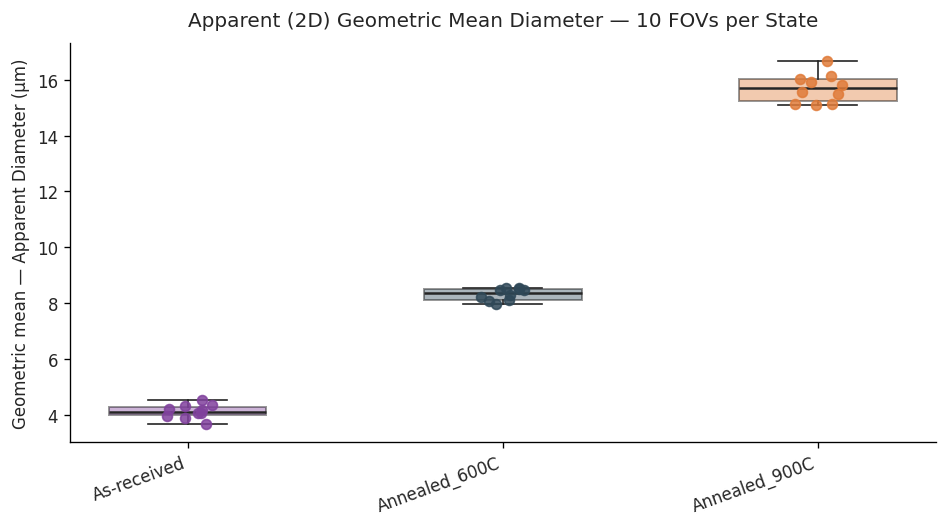

In [4]:
fig_app = pipeline.boxplot(result_apparent, metric="gmean", figsize=(8, 4.5))
fig_app.axes[0].set_title(
    "Apparent (2D) Geometric Mean Diameter — 10 FOVs per State", pad=10
)
fig_app.tight_layout()
fig_app.savefig(DATA_DIR / "boxplot_apparent_gmean.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Stereological correction — two-step method

For each FOV we apply `two_step()` to the apparent diameters.  This iterates
the Saltykov unfolding over bin counts 10–20, fits a lognormal PDF to the 3D
frequency histogram, and returns the best-fit `geometric_mean` and
multiplicative standard deviation `shape`.

We sample the corrected 3D distribution and write a new batch CSV in the
same format, ready for the second pipeline run.

In [5]:
corrected_batch_files = {}   # state name -> Path
correction_rows = []
rng_sample = np.random.default_rng(0)

for sr in result_apparent.states:
    state_name = sr.name
    batch_rows = []

    for fr in sr.fields:
        fov_id = fr.fov_id   # e.g. "fov01"

        # Two-step stereological correction on this FOV's apparent diameters
        ts = two_step(fr.data, bin_range=(10, 20))

        # ts.shape is the multiplicative std dev exp(σ_ln) → σ_ln = log(shape)
        sigma_ln = np.log(ts.shape)
        corrected_values = rng_sample.lognormal(
            mean=np.log(ts.geometric_mean),
            sigma=sigma_ln,
            size=len(fr.data.values),
        )

        for grain_idx, val in enumerate(corrected_values, start=1):
            batch_rows.append({
                "label": f"{state_name}_{fov_id}_grain{grain_idx:03d}",
                "diameter_um": val,
            })

        correction_rows.append({
            "state": state_name,
            "fov": fov_id,
            "apparent_gmean": float(np.exp(np.mean(np.log(fr.data.values)))),
            "corrected_gmean": ts.geometric_mean,
            "shape": ts.shape,
            "best_n_bins": ts.best_n_bins,
        })

    csv_path = DATA_DIR / f"{state_name}_corrected.csv"
    pd.DataFrame(batch_rows).to_csv(csv_path, index=False)
    corrected_batch_files[state_name] = csv_path

print("── Two-step correction per FOV ──")
display(pd.DataFrame(correction_rows).round(3))

── Two-step correction per FOV ──


,state,fov,apparent_gmean,corrected_gmean,shape,best_n_bins
0,As-received,fov01,4.522,5.449,1.401,11
1,As-received,fov02,4.318,5.344,1.533,10
2,As-received,fov03,3.682,4.593,1.491,10
3,As-received,fov04,4.073,4.948,1.473,12
4,As-received,fov05,3.957,4.517,1.430,11
5,As-received,fov06,4.353,5.101,1.558,10
6,As-received,fov07,4.050,5.224,1.405,10
7,As-received,fov08,4.162,4.849,1.456,10
8,As-received,fov09,4.216,5.086,1.495,11
9,As-received,fov10,3.890,4.930,1.435,11


## 4. Corrected (3D) diameter pipeline

In [6]:
result_corrected = run_batch(
    states=corrected_batch_files,
    measurement_column="diameter_um",
    unit="µm",
    label_column="label",
    label="Corrected 3D Diameter",
    metric="gmean",
)

print("── Summary: Corrected (3D) Diameters ──")
display(
    result_corrected.summary[
        ["state", "fov", "n", "amean", "gmean", "gmean_ci_low", "gmean_ci_high", "median"]
    ].round(3)
)

── Summary: Corrected (3D) Diameters ──


,state,fov,n,amean,gmean,gmean_ci_low,gmean_ci_high,median
0,As-received,fov01,150,5.856,5.566,5.282,5.865,5.669
1,As-received,fov02,150,5.625,5.046,4.687,5.431,4.828
2,As-received,fov03,150,5.024,4.666,4.379,4.971,4.693
3,As-received,fov04,150,5.172,4.836,4.552,5.139,4.813
4,As-received,fov05,150,4.692,4.412,4.168,4.671,4.385
5,As-received,fov06,150,5.528,5.128,4.821,5.454,5.049
6,As-received,fov07,150,5.185,4.920,4.669,5.184,4.843
7,As-received,fov08,150,5.336,4.970,4.673,5.285,5.166
8,As-received,fov09,150,5.608,5.141,4.807,5.498,5.047
9,As-received,fov10,150,5.417,5.071,4.775,5.385,5.255


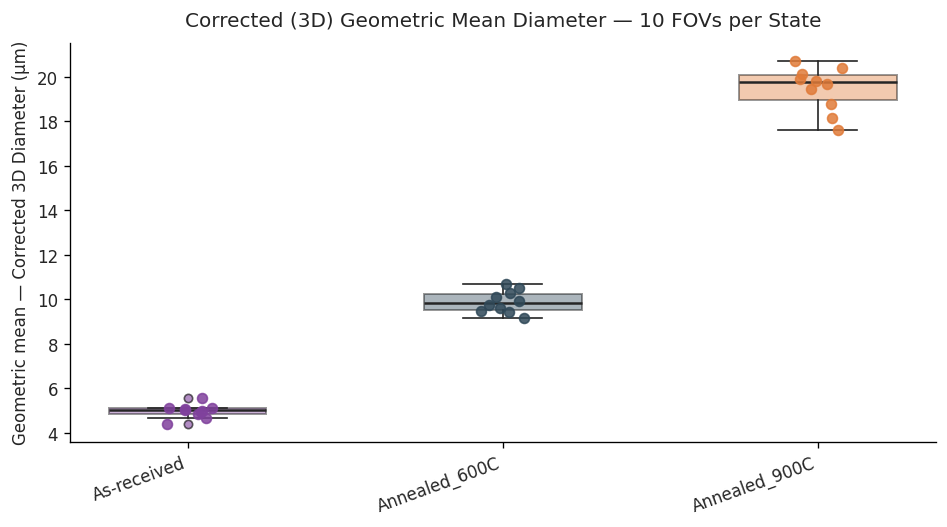

In [7]:
fig_corr = pipeline.boxplot(result_corrected, metric="gmean", figsize=(8, 4.5))
fig_corr.axes[0].set_title(
    "Corrected (3D) Geometric Mean Diameter — 10 FOVs per State", pad=10
)
fig_corr.tight_layout()
fig_corr.savefig(DATA_DIR / "boxplot_corrected_gmean.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Apparent vs Corrected comparison

Side-by-side view with dashed reference lines at the simulation ground-truth values.

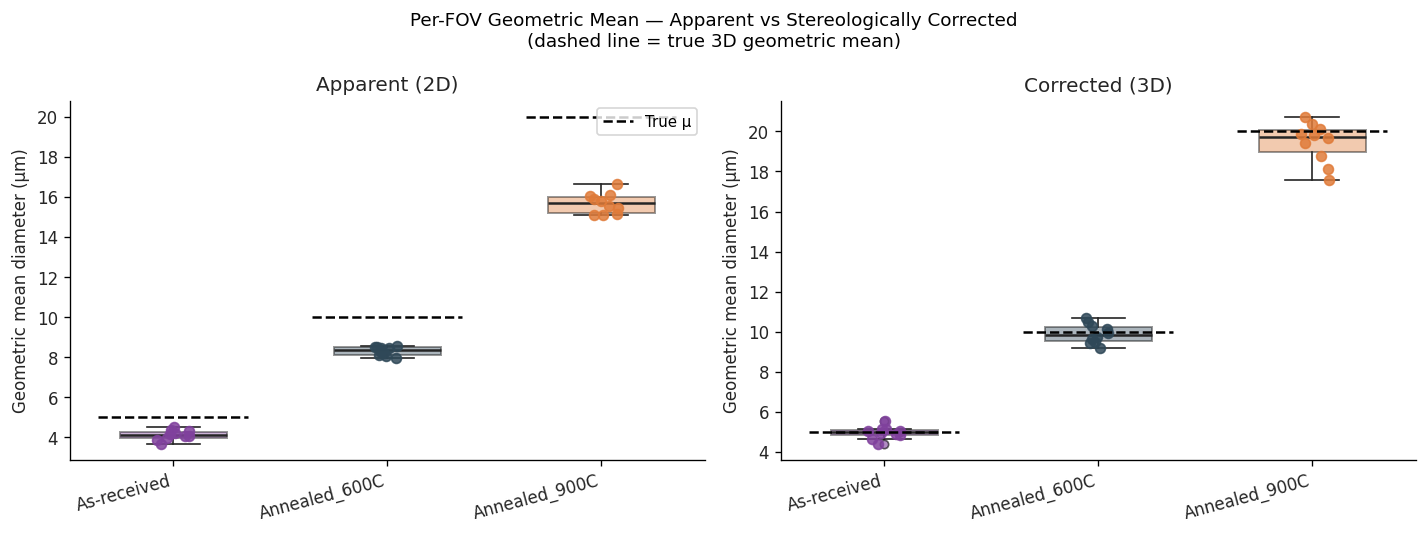

In [8]:
from stamp.plot import _C_TEXT, _apply_style

colors = [pipeline._STATE_COLORS[i] for i in range(len(STATES))]
state_names = list(STATES.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, (result, title) in zip(
    axes,
    [(result_apparent, "Apparent (2D)"), (result_corrected, "Corrected (3D)")],
):
    rng_jit = np.random.default_rng(1)
    for i, state_name in enumerate(state_names):
        vals = result.summary[result.summary["state"] == state_name]["gmean"].values
        color = colors[i]
        ax.boxplot(
            vals,
            positions=[i + 1],
            widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.4, linewidth=1.2),
            medianprops=dict(color=_C_TEXT, linewidth=1.5),
            whiskerprops=dict(color=_C_TEXT, linewidth=1.0),
            capprops=dict(color=_C_TEXT, linewidth=1.0),
            flierprops=dict(marker="o", markerfacecolor=color, markersize=5, alpha=0.6),
            manage_ticks=False,
        )
        jitter = rng_jit.uniform(-0.08, 0.08, len(vals))
        ax.scatter(
            np.array([i + 1]) + jitter, vals,
            color=color, alpha=0.85, s=35, zorder=3,
        )
        true_mu = STATES[state_name]["mu"]
        ax.hlines(
            true_mu, i + 0.65, i + 1.35,
            colors="black", linewidths=1.5, linestyles="--", zorder=4,
            label="True μ" if i == 0 else None,
        )

    ax.set_xticks(range(1, len(state_names) + 1))
    ax.set_xticklabels(state_names, rotation=15, ha="right")
    ax.set_ylabel("Geometric mean diameter (µm)")
    ax.set_title(title)
    if ax is axes[0]:
        ax.legend(fontsize=9)
    _apply_style(ax)

fig.suptitle(
    "Per-FOV Geometric Mean — Apparent vs Stereologically Corrected\n"
    "(dashed line = true 3D geometric mean)",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(DATA_DIR / "comparison_apparent_vs_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Export summaries and check recovery accuracy

In [9]:
pipeline.export_csv(result_apparent,  DATA_DIR / "summary_apparent.csv")
pipeline.export_csv(result_corrected, DATA_DIR / "summary_corrected.csv")

print("Exported:")
for name in ("summary_apparent.csv", "summary_corrected.csv"):
    print(f"  {DATA_DIR / name}")

print("\n── Recovery accuracy ──")
print(f"{'State':<20} {'True μ (µm)':>12} {'App. gmean':>12} {'App. bias':>10} {'Corr. gmean':>12} {'Corr. err':>10}")
print("-" * 80)
for state_name, params in STATES.items():
    true_mu    = params["mu"]
    app_mean   = result_apparent.summary[ result_apparent.summary["state"] == state_name]["gmean"].mean()
    corr_mean  = result_corrected.summary[result_corrected.summary["state"] == state_name]["gmean"].mean()
    app_bias   = (app_mean  - true_mu) / true_mu * 100
    corr_err   = (corr_mean - true_mu) / true_mu * 100
    print(f"{state_name:<20} {true_mu:>12.2f} {app_mean:>12.3f} {app_bias:>+9.1f}% {corr_mean:>12.3f} {corr_err:>+9.1f}%")

Exported:
  notebooks\data\multi_state_batch\summary_apparent.csv
  notebooks\data\multi_state_batch\summary_corrected.csv

── Recovery accuracy ──
State                 True μ (µm)   App. gmean  App. bias  Corr. gmean  Corr. err
--------------------------------------------------------------------------------
As-received                  5.00        4.122     -17.6%        4.975      -0.5%
Annealed_600C               10.00        8.312     -16.9%        9.899      -1.0%
Annealed_900C               20.00       15.703     -21.5%       19.447      -2.8%
